# HPV status prediction with Generalized Linear Models (GLM)

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/readii_2_roqc


In [2]:
from damply import dirs
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, roc_curve, roc_auc_score, precision_recall_curve

from readii_2_roqc.analysis import bootstrap_auc

In [3]:
radcure_train = pd.read_csv(dirs.RESULTS / "TCIA_RADCURE_windowed/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status/TRAIN/original_full_labelled_features.csv", index_col=0)

radcure_test = pd.read_csv(dirs.RESULTS / "TCIA_RADCURE_windowed/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status/TEST/original_full_labelled_features.csv", index_col=0)
hn1_test = pd.read_csv(dirs.RESULTS / "TCIA_HEAD-NECK-RADIOMICS-HN1_windowed/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status/original_full_labelled_features.csv", index_col=0)

2026-07-15 | WARNING | Environment variable 'RESULTS' is not set. Using default path relative to project root.


# R glmnet result plotting

In [5]:
glmnet_train = pd.read_csv(dirs.RESULTS / "TCIA_RADCURE_windowed/prediction/choi_opc_hpv_2020_hpv_status/glmnet_bootstrap_radcure_train.csv")
glmnet_test = pd.read_csv(dirs.RESULTS / "TCIA_RADCURE_windowed/prediction/choi_opc_hpv_2020_hpv_status/glmnet_bootstrap_radcure_test.csv")
glmnet_valid = pd.read_csv(dirs.RESULTS / "TCIA_HEAD-NECK-RADIOMICS-HN1_windowed/prediction/choi_opc_hpv_2020_hpv_status/glmnet_bootstrap_hn1_valid.csv")

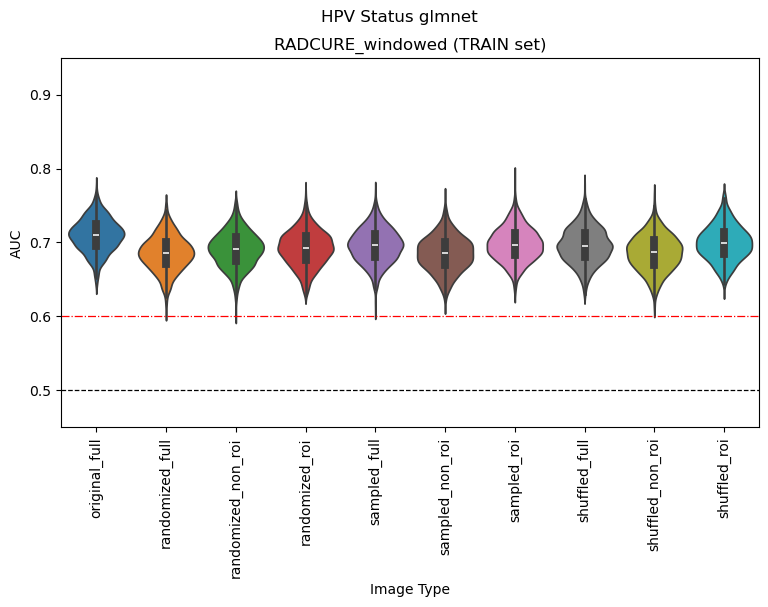

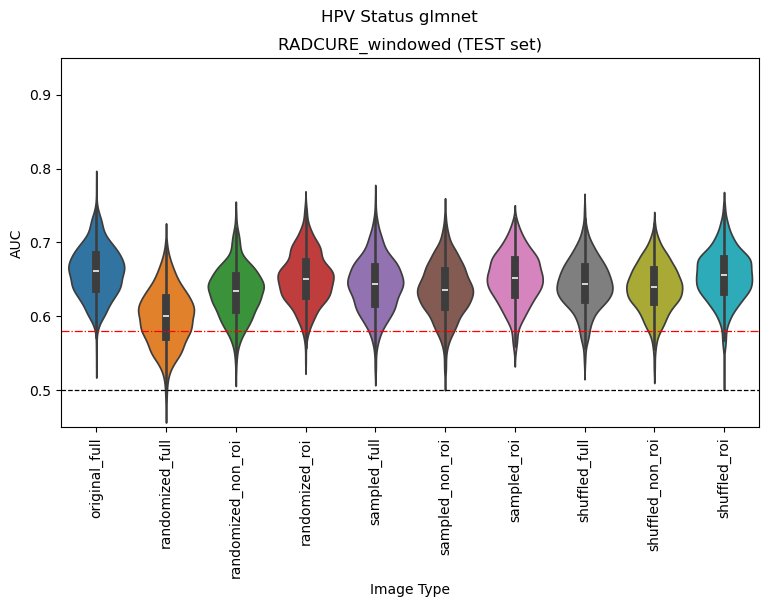

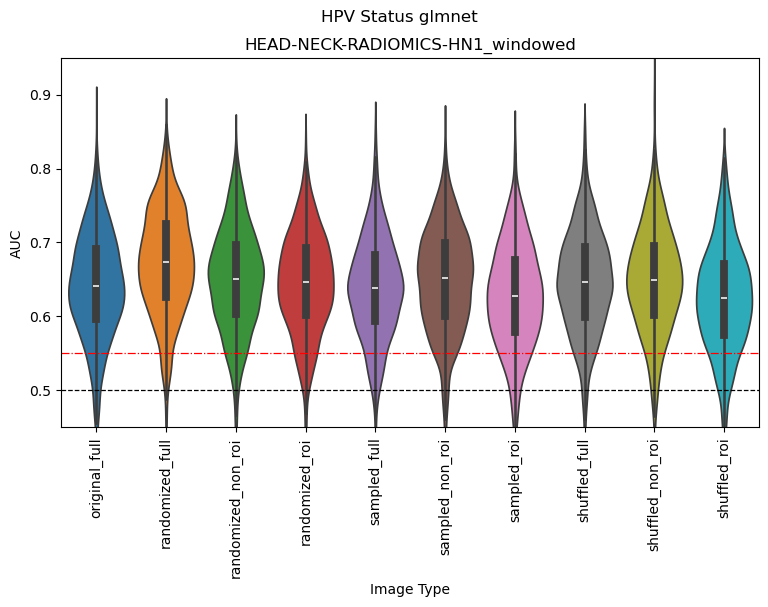

In [6]:
from readii_2_roqc.visualization import prediction_violin
import matplotlib.pyplot as plt

y_lower = 0.45
y_upper = 0.95

train_plot = prediction_violin(
    predictions = glmnet_train,
    signature_name = "Choi HPV",
    dataset_name = 'RADCURE train',
    split = "Train",
    title_text = "HPV Status glmnet",
    subtitle_text = "RADCURE_windowed (TRAIN set)",
    y_label= "AUC",
    x_label= "Image Type",
    h_line=0.5,
    vol_line=0.6,
    y_lower = y_lower,
    y_upper = y_upper
)

test_plot = prediction_violin(
    predictions = glmnet_test,
    signature_name = "Choi HPV",
    dataset_name = 'RADCURE test',
    split = "Test",
    title_text = "HPV Status glmnet",
    subtitle_text = "RADCURE_windowed (TEST set)",
    y_label= "AUC",
    x_label= "Image Type",
    h_line=0.5,
    vol_line=0.58,
    y_lower = y_lower,
    y_upper = y_upper
)

valid_plot = prediction_violin(
    predictions = glmnet_valid,
    signature_name = "Choi HPV",
    dataset_name = 'HEAD-NECK-RADIOMICS-HN1',
    title_text= "HPV Status glmnet",
    subtitle_text = "HEAD-NECK-RADIOMICS-HN1_windowed",
    y_label= "AUC",
    x_label= "Image Type",
    h_line=0.5,
    vol_line=0.55,
    y_lower = y_lower,
    y_upper = y_upper
)

# Logistic Regression 

In [4]:
model = LogisticRegression(max_iter=1000, random_state=10, solver='newton-cg')

pred_col = 'hpv_status'
X_train = radcure_train.drop(columns=[pred_col])
y_train = radcure_train[pred_col]

model.fit(X_train, y_train)

train_predictions = model.predict(X_train)

In [5]:
X_test = radcure_test.drop(columns=[pred_col])
y_test = radcure_test[pred_col]
predictions = model.predict(X_test)

X_valid = hn1_test.drop(columns=[pred_col])
y_valid = hn1_test[pred_col]
val_predictions = model.predict(X_valid)

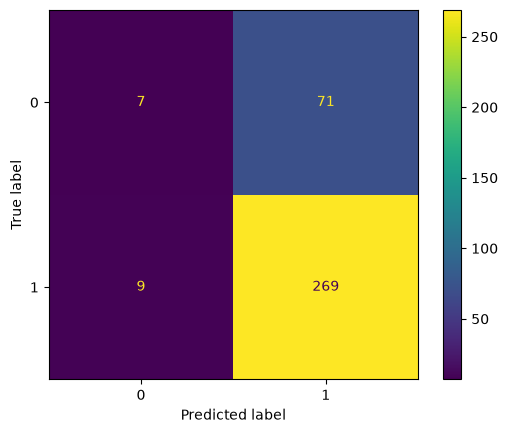

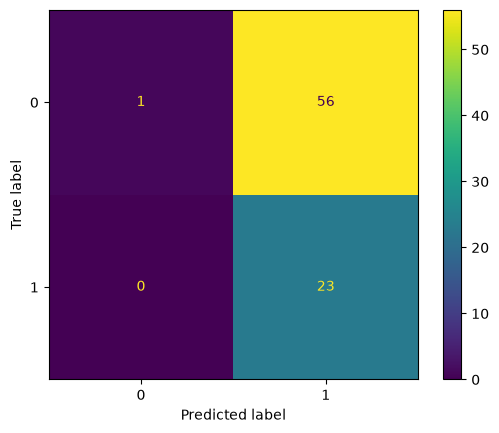

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test,predictions)

cm_display = ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot()

val_cm = confusion_matrix(y_valid,val_predictions)  
val_cm_display = ConfusionMatrixDisplay(val_cm, display_labels=model.classes_).plot()

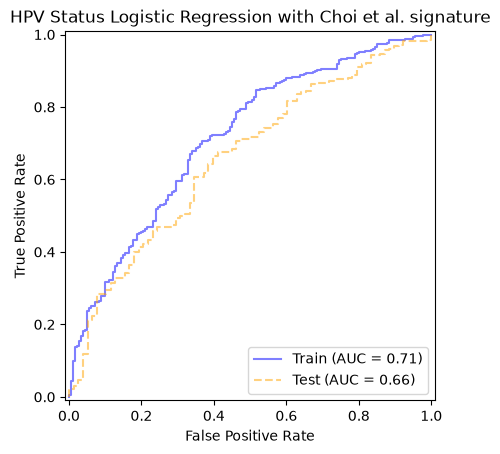

In [7]:
tr_y_score = model.decision_function(X_train)
y_score = model.decision_function(X_test)
val_y_score = model.decision_function(X_valid)

tr_auc = roc_auc_score(y_train, tr_y_score)
auc = roc_auc_score(y_test, y_score)
val_auc = roc_auc_score(y_valid, val_y_score)

tr_fpr, tr_tpr, _ = roc_curve(y_train, tr_y_score, pos_label=model.classes_[1])
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=model.classes_[1])
val_fpr, val_tpr, _ = roc_curve(y_valid, val_y_score, pos_label=model.classes_[1])

roc_display = RocCurveDisplay(
    fpr=[tr_fpr, fpr],#, val_fpr], 
    tpr=[tr_tpr, tpr],#, val_tpr], 
    roc_auc=[tr_auc, auc],#, val_auc],
    name=["Train", "Test"]).plot(
        curve_kwargs=[
            {"linestyle": "-", "color": "blue"}, 
            {"linestyle": "--", "color": "orange"}, 
            #{"linestyle": "-.", "color": "green"}
            ]
        )


title = roc_display.ax_.set_title("HPV Status Logistic Regression with Choi et al. signature")

In [ ]:
# now to loop over all the image types
# dataset = "TCIA_HEAD-NECK-RADIOMICS-HN1_windowed"
# features_dir = dirs.RESULTS / f"{dataset}/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status"

dataset = "TCIA_RADCURE_windowed"
features_dir = dirs.RESULTS / f"{dataset}/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status/TEST"


feature_file_list = sorted(features_dir.glob("*labelled_features.csv"))


predictions_dict = {}
for file in feature_file_list:
    test_data = pd.read_csv(file, index_col=0)
    img_type = file.name.removesuffix('_labelled_features.csv')

    X_test = test_data.drop(columns=[pred_col])
    y_test = test_data[pred_col]
    y_score = model.decision_function(X_test)

    auc = roc_auc_score(y_test, y_score)
    precision, recall, _ = precision_recall_curve(y_test, y_score, pos_label=model.classes_[1])
    fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=model.classes_[1])

    predictions_dict[img_type] = {
        'Model': file.name.removesuffix('_labelled_features.csv'),
        'AUC': auc,
        'Recall': recall[1],
        'Prec.': precision[1],
        'F1': 2 * (precision[1] * recall[1]) / (precision[1] + recall[1]),
        'fpr': fpr,
        'tpr': tpr
    }

predictions_df = pd.DataFrame(columns=['Model', 'AUC', 'Recall', 'Prec.', 'F1', 'fpr', 'tpr']).from_dict(predictions_dict, orient='index')
predictions_df

readii_roc_display = RocCurveDisplay(
    fpr=predictions_df['fpr'].to_list(), 
    tpr=predictions_df['tpr'].to_list(), 
    roc_auc=predictions_df['AUC'].to_list(),
    name=predictions_df['Model'].to_list()).plot(
        curve_kwargs=[
            {"linestyle": "-", "color": "#1f77b4"},
            {"linestyle": "--", "color": "#00540D"},
            {"linestyle": "--", "color": "#2ca02c"},
            {"linestyle": "--", "color": "#00ef20"},  
            {"linestyle": "-.", "color": "#915200"},
            {"linestyle": "-.", "color": "#d37700"},
            {"linestyle": "-.", "color": "#ffa13c"},
            {"linestyle": ":", "color": "#69006f"},
            {"linestyle": ":", "color": "#be01dbff"},
            {"linestyle": ":", "color": "#d94fff"},
            ]
        )


In [ ]:
dataset = "TCIA_RADCURE_windowed"
split = "TEST"
features_dir = dirs.RESULTS / f"{dataset}/features/pyradiomics/original_512_512_n/labelled/choi_opc_hpv_2020_hpv_status/{split}"

feature_file_list = sorted(features_dir.glob("*labelled_features.csv"))

bootstrap_results = {}

for file in feature_file_list:
    test_data = pd.read_csv(file, index_col=0)
    img_type = file.name.removesuffix('_labelled_features.csv')

    X_test = test_data.drop(columns=[pred_col])
    y_test = test_data[pred_col]
    y_score = model.decision_function(X_test)

    bootstrap_res, low_conf_int, high_conf_int = bootstrap_auc(y_test, y_score)
    bootstrap_results[img_type] = bootstrap_res

bootstrap_results_df = pd.DataFrame.from_dict(bootstrap_results)


In [ ]:
bootstrap_results_df.to_csv(dirs.RESULTS / f"{dataset}" / "prediction" / "choi_opc_hpv_2020_hpv_status" / f"lr_bootstrap_hn1_{split.lower()}.csv", index=False)

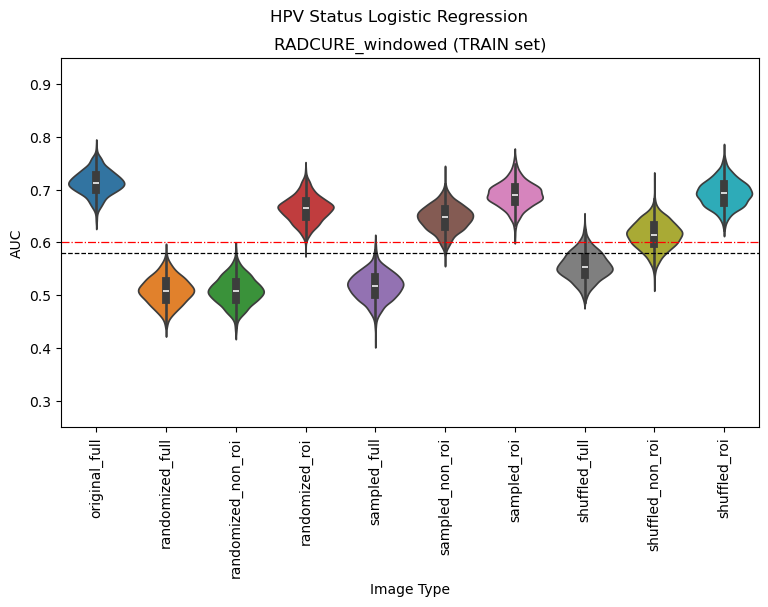

In [36]:
from readii_2_roqc.visualization import prediction_violin

fig = prediction_violin(
    predictions = bootstrap_results_df,
    signature_name = "Choi HPV",
    dataset_name = dataset,
    split = "Test",
    title_text = "HPV Status Logistic Regression",
    subtitle_text = "RADCURE_windowed (TRAIN set)",
    y_label= "AUC",
    x_label= "Image Type",
    h_line=0.58,
    vol_line=0.6,
    y_lower = 0.25,
    y_upper = 0.95
)

## Mesh Volume prediction

In [4]:
full_RADCURE = pd.read_csv(dirs.RESULTS / "TCIA_RADCURE_windowed/features/pyradiomics/original_512_512_n/linear_all_images_features/original_full_features.csv", index_col=0)
full_HN1 = pd.read_csv(dirs.RESULTS / "TCIA_HEAD-NECK-RADIOMICS-HN1_windowed/features/pyradiomics/original_512_512_n/linear_all_images_features/original_full_features.csv", index_col=0)

RADCURE_full = full_RADCURE[['original_shape_MeshVolume']]
HN1_full = full_HN1[['original_shape_MeshVolume']]

tr_RADCURE_vol = RADCURE_full.loc[radcure_train.index]
test_RADCURE_vol = RADCURE_full.loc[radcure_test.index]
val_HN1_vol = HN1_full.loc[hn1_test.index]

In [5]:
vol_model = LogisticRegression(max_iter=1000, random_state=10)

pred_col = 'hpv_status'

y_train = radcure_train[pred_col]

vol_model.fit(tr_RADCURE_vol, y_train)

train_vol_predictions = vol_model.predict(tr_RADCURE_vol)
vol_predictions = vol_model.predict(test_RADCURE_vol)
val_vol_predictions = vol_model.predict(val_HN1_vol)

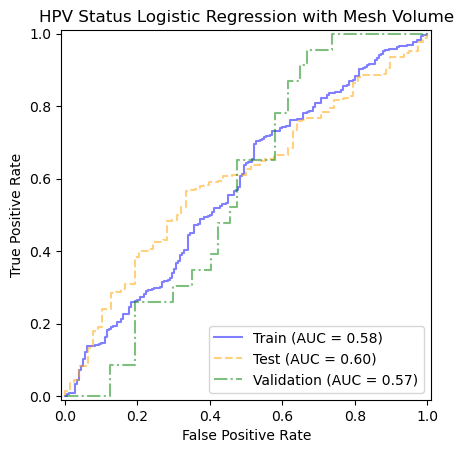

In [11]:
tr_vol_y_score = vol_model.decision_function(tr_RADCURE_vol)
y_vol_score = vol_model.decision_function(test_RADCURE_vol)
val_vol_y_score = vol_model.decision_function(val_HN1_vol)

tr_vol_auc = roc_auc_score(y_train, tr_vol_y_score)
vol_auc = roc_auc_score(y_test, y_vol_score)
val_vol_auc = roc_auc_score(y_valid, val_vol_y_score)

tr_vol_fpr, tr_vol_tpr, _ = roc_curve(y_train, tr_vol_y_score, pos_label=vol_model.classes_[1])
vol_fpr, vol_tpr, _ = roc_curve(y_test, y_vol_score, pos_label=vol_model.classes_[1])
val_vol_fpr, val_vol_tpr, _ = roc_curve(y_valid, val_vol_y_score, pos_label=vol_model.classes_[1])

vol_roc_display = RocCurveDisplay(
    fpr=[tr_vol_fpr, vol_fpr, val_vol_fpr], 
    tpr=[tr_vol_tpr, vol_tpr, val_vol_tpr], 
    roc_auc=[tr_vol_auc, vol_auc, val_vol_auc],
    name=["Train", "Test", "Validation"]).plot(
        curve_kwargs=[
            {"linestyle": "-", "color": "blue"}, 
            {"linestyle": "--", "color": "orange"}, 
            {"linestyle": "-.", "color": "green"}
            ]
        )

vol_title = vol_roc_display.ax_.set_title("HPV Status Logistic Regression with Mesh Volume")

## Using statsmodels for GLM

In [ ]:
import statsmodels.api as sm 

In [ ]:
data = sm.datasets.star98.load()
data.exog = sm.add_constant(data.exog, prepend=False)

In [ ]:
print(data.endog.head())

In [ ]:
print(data.exog.head())

In [ ]:
radcure_train.head()

In [ ]:
import statsmodels.api as sm

endog = 'hpv_status'

radcure_train['const'] = 1

glm_gauss = sm.GLM(radcure_train[endog], radcure_train.drop(columns=[endog]), family=sm.families.Gaussian())

In [ ]:
res = glm_gauss.fit()
print(res.summary())

In [ ]:
radcure_test['const'] = 1
res.predict(radcure_test.drop(columns=[endog]))